Shape: (541909, 8)


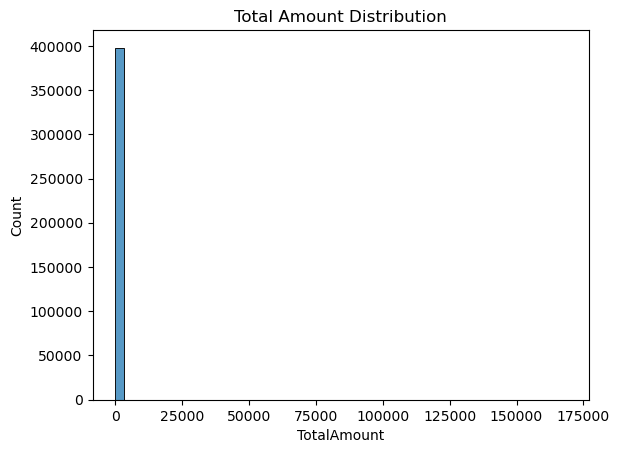

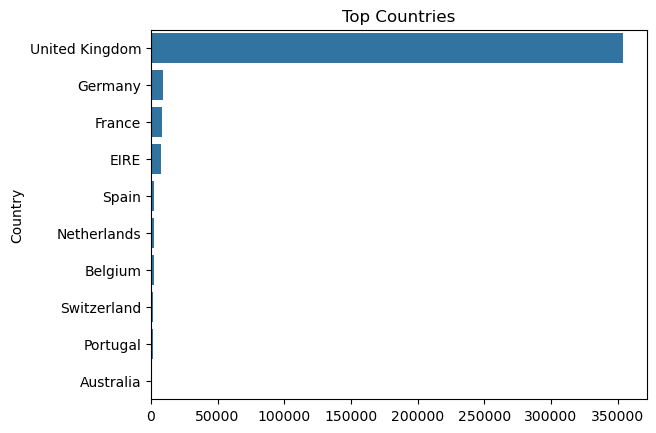

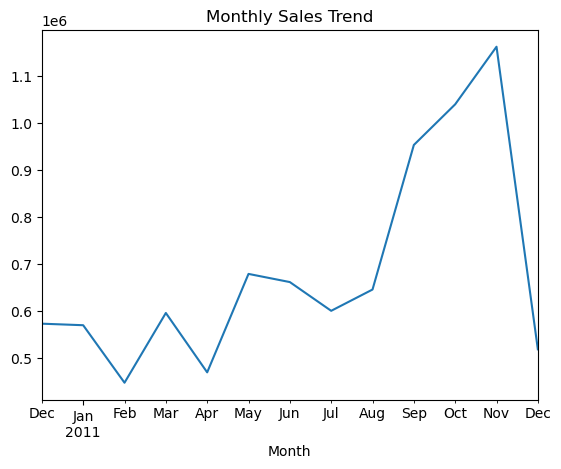

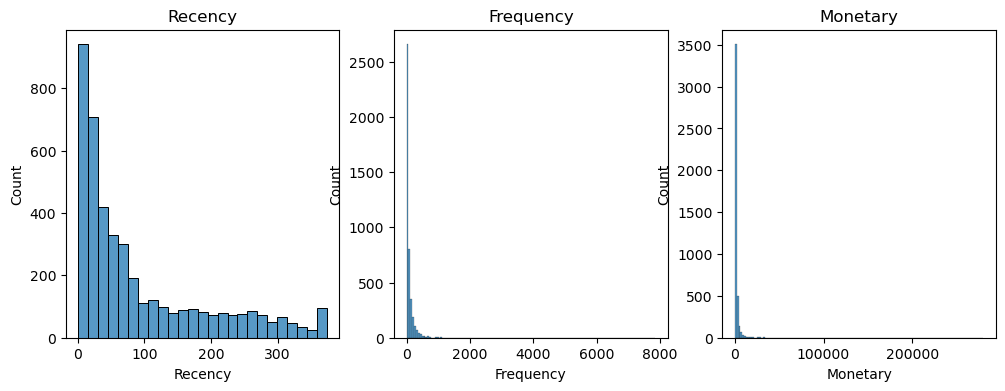

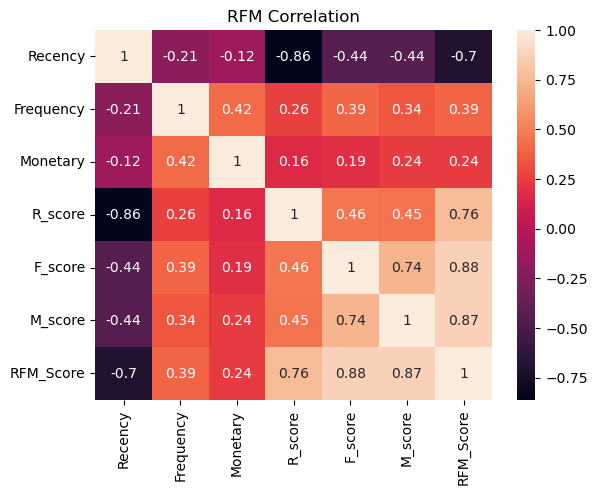

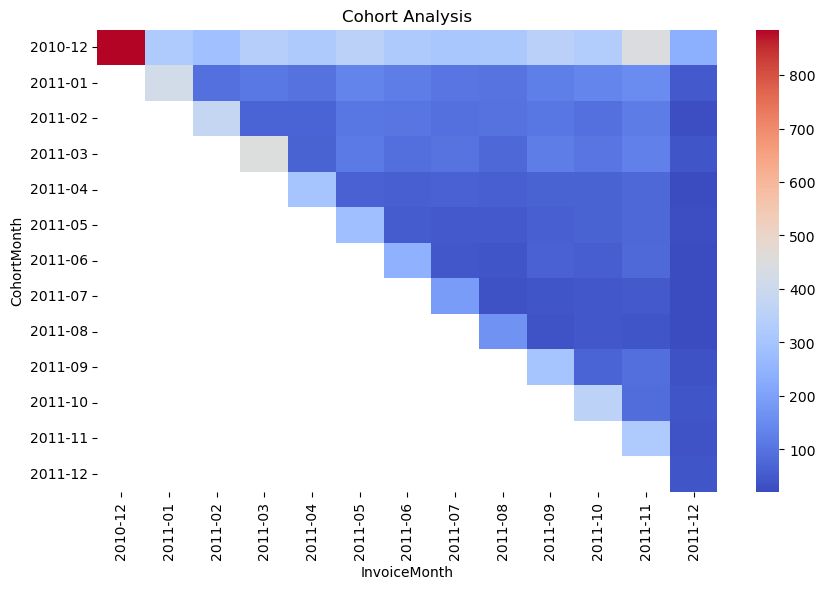

Accuracy: 0.9988479262672811
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       429
           1       1.00      1.00      1.00       439

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



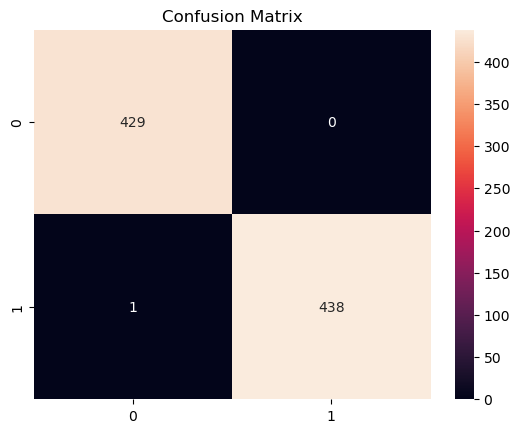

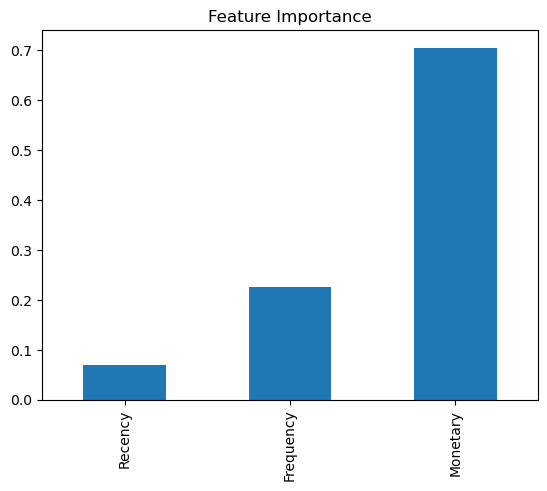

Project Completed Successfully


In [6]:
# =========================================
# RFM ANALYSIS + COHORT + ML PREDICTION
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load Dataset
# -----------------------------
df=pd.read_csv("online_retail.csv")
print("Shape:", df.shape)

# -----------------------------
# Data Cleaning
# -----------------------------
df.dropna(subset=['CustomerID'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# -----------------------------
# Basic EDA
# -----------------------------
plt.figure()
sns.histplot(df['TotalAmount'], bins=50)
plt.title("Total Amount Distribution")
plt.show()

plt.figure()
top_country = df['Country'].value_counts().head(10)
sns.barplot(x=top_country.values, y=top_country.index)
plt.title("Top Countries")
plt.show()

# -----------------------------
# Monthly Sales Trend
# -----------------------------
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

# -----------------------------
# RFM Analysis
# -----------------------------
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# -----------------------------
# RFM Distribution
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'])
plt.title("Recency")

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'])
plt.title("Monetary")

plt.show()

# -----------------------------
# RFM Segmentation
# -----------------------------
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

# -----------------------------
# Heatmap
# -----------------------------
plt.figure()
sns.heatmap(rfm.corr(), annot=True)
plt.title("RFM Correlation")
plt.show()

# -----------------------------
# Cohort Analysis
# -----------------------------
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

cohort_data = df.groupby(['CohortMonth','InvoiceMonth'])['CustomerID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='InvoiceMonth', values='CustomerID')

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, cmap='coolwarm')
plt.title("Cohort Analysis")
plt.show()

# -----------------------------
# ML: Predict High Value Customers
# -----------------------------
rfm['HighValue'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

# Features
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValue']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.Series(rf.feature_importances_, index=['Recency','Frequency','Monetary'])
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

print("Project Completed Successfully")